In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [2]:
np.random.seed(42)
n = 500  # number of students

data = pd.DataFrame({
    "lms_logins_per_week": np.random.randint(1, 15, n),
    "assignment_delay_days": np.random.randint(0, 10, n),
    "attendance_rate": np.random.uniform(50, 100, n),
    "avg_sleep_hours": np.random.uniform(4, 9, n),
    "sentiment_score": np.random.uniform(-1, 1, n),
    "study_hours_per_week": np.random.uniform(2, 30, n)
})

data.head()

,lms_logins_per_week,assignment_delay_days,attendance_rate,avg_sleep_hours,sentiment_score,study_hours_per_week
0,7,9,74.537439,5.960756,0.146083,3.918151
1,4,9,86.144805,4.897487,0.865461,23.368348
2,13,5,91.043074,7.768494,0.150327,13.432578
3,11,0,85.922864,7.944035,-0.041291,23.258965
4,8,3,76.751837,4.868767,-0.372545,27.301020


In [3]:
risk_score = (
    (15 - data["lms_logins_per_week"]) +
    data["assignment_delay_days"] +
    (100 - data["attendance_rate"]) * 0.1 +
    (7 - data["avg_sleep_hours"]) * 2 -
    data["sentiment_score"] * 3
)

data["burnout_risk"] = pd.cut(
    risk_score,
    bins=[-100,10,20,100],
    labels=["Low","Medium","High"]
)

data.head()

,lms_logins_per_week,assignment_delay_days,attendance_rate,avg_sleep_hours,sentiment_score,study_hours_per_week,burnout_risk
0,7,9,74.537439,5.960756,0.146083,3.918151,High
1,4,9,86.144805,4.897487,0.865461,23.368348,High
2,13,5,91.043074,7.768494,0.150327,13.432578,Low
3,11,0,85.922864,7.944035,-0.041291,23.258965,Low
4,8,3,76.751837,4.868767,-0.372545,27.301020,Medium


In [4]:
data["burnout_risk"].value_counts()

,count
burnout_risk,
Medium,287
High,121
Low,92


In [5]:
X = data.drop("burnout_risk", axis=1)

encoder = LabelEncoder()
y = encoder.fit_transform(data["burnout_risk"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.95      0.67      0.78        30
           1       0.87      0.68      0.76        19
           2       0.75      0.94      0.83        51

    accuracy                           0.81       100
   macro avg       0.86      0.76      0.79       100
weighted avg       0.83      0.81      0.81       100



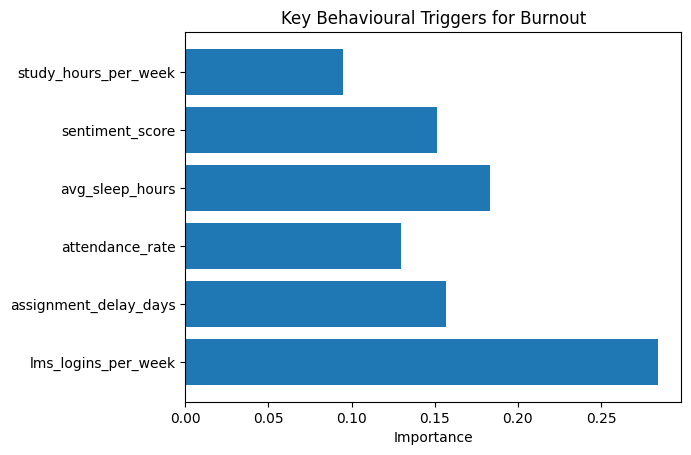

In [7]:
importance = model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("Key Behavioural Triggers for Burnout")
plt.xlabel("Importance")
plt.show()

In [8]:
def intervention(level):
    if level == "High":
        return "Immediate counseling and advisor intervention"
    elif level == "Medium":
        return "Weekly mentoring and workload monitoring"
    else:
        return "Maintain engagement programs"

data["recommendation"] = data["burnout_risk"].astype(str).apply(intervention)

data.head()

,lms_logins_per_week,assignment_delay_days,attendance_rate,avg_sleep_hours,sentiment_score,study_hours_per_week,burnout_risk,recommendation
0,7,9,74.537439,5.960756,0.146083,3.918151,High,Immediate counseling and advisor intervention
1,4,9,86.144805,4.897487,0.865461,23.368348,High,Immediate counseling and advisor intervention
2,13,5,91.043074,7.768494,0.150327,13.432578,Low,Maintain engagement programs
3,11,0,85.922864,7.944035,-0.041291,23.258965,Low,Maintain engagement programs
4,8,3,76.751837,4.868767,-0.372545,27.301020,Medium,Weekly mentoring and workload monitoring


In [9]:
# Create numerical burnout risk score (0–100)
normalized_score = (risk_score - risk_score.min()) / (
    risk_score.max() - risk_score.min()
)

data["risk_score"] = (normalized_score * 100).round(2)

data[["burnout_risk", "risk_score"]].head()

,burnout_risk,risk_score
0,High,67.58
1,High,72.51
2,Low,25.91
3,Low,19.74
4,Medium,58.08


In [10]:
sample_student = pd.DataFrame([{
    "lms_logins_per_week": 3,
    "assignment_delay_days": 7,
    "attendance_rate": 60,
    "avg_sleep_hours": 5,
    "sentiment_score": -0.4,
    "study_hours_per_week": 6
}])

prediction = model.predict(sample_student)
label = encoder.inverse_transform(prediction)[0]

print("Predicted Burnout Level:", label)
print("Recommended Action:", intervention(label))

Predicted Burnout Level: High
Recommended Action: Immediate counseling and advisor intervention


In [11]:
data.to_csv("student_burnout_data.csv", index=False)